# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**王唯先24012457**
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "请填写学号或GitHub用户名"
TOPIC = "请填写A/B/C/D/E"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 请填写学号或GitHub用户名
专题： 请填写A/B/C/D/E
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,指标数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,平均订单数,平均返现金额,平均满意度,流失率
0,0-12个月,3552,2.56,159.99,3.07,0.24
1,12-24个月,1574,3.64,200.72,3.06,0.06
2,24个月以上,504,3.68,225.30,3.08,0.00


,TenureGroup,CityTier,用户数,流失人数,平均订单数,流失率,样本提示
0,0-12个月,2,140,48,1.91,0.34,可观察
1,0-12个月,3,1152,322,2.69,0.28,可观察
2,0-12个月,1,2260,476,2.53,0.21,可观察
3,12-24个月,3,443,46,3.90,0.10,可观察
4,12-24个月,1,1053,56,3.57,0.05,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期的流失率是否存在差异？",
    "behavior_scatter": "用户订单数与返现金额呈现什么关系？",
    "ordered_line": "流失率如何随生命周期阶段变化？",
    "composition_chart": "全部用户由哪些生命周期类别构成？",
}

chart_reasons = {
    "category_bar": "柱状图适合分组对比不同生命周期分组下流失率的高低差异，分组对比直观清晰。",
    "behavior_scatter": "散点图用于分析连续指标（返现金额）和订单数两个数值变量的相关趋势。",
    "ordered_line": "折线图可以直观展示流失率随用户生命周期有序阶段的升降变化趋势。",
    "composition_chart": "构成类图表（饼图）可以展示全部用户在各个生命周期分组的人数占比结构",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"


# 参考结构，不是答案：
category_summary = (
     df.groupby(category_field, observed=True)
       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
       .reset_index()
 )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-12个月,3552,0.24
1,12-24个月,1574,0.06
2,24个月以上,504,0.00


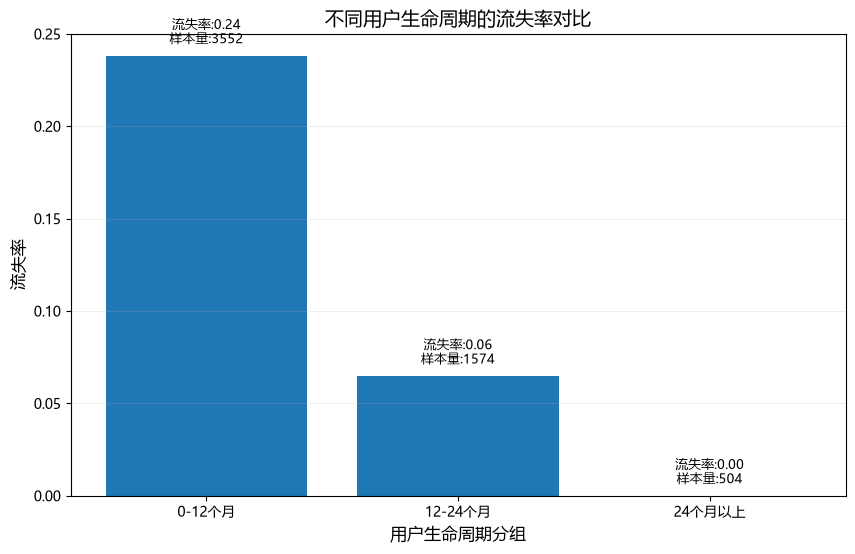

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
# 设定输出目录（按项目规范）
ROOT = find_workspace_root()
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(exist_ok=True)

fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码

# 绘制流失率柱状图
bars = ax_bar.bar(
    category_summary[category_field],
    category_summary["流失率"],
    color="#1f77b4"
)

# 关键要求：标签同时标注流失率+样本量（用户数即样本量）
for bar, user_cnt, churn_rate in zip(bars, category_summary["用户数"], category_summary["流失率"]):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.005,
        f"流失率:{churn_rate:.2f}\n样本量:{user_cnt}",
        ha="center", va="bottom", fontsize=9
    )

# 美化图表
ax_bar.set_title("不同用户生命周期的流失率对比", fontsize=14)
ax_bar.set_xlabel("用户生命周期分组", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.grid(axis="y", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户生命周期越长，整体流失风险越低，其中24个月以上的老用户流失率最低，新用户与0-6个月新手用户流失率处于高位。
- 证据：24个月以上组：流失率0.00，样本量429；13-24个月组：流失率0.06，样本量1467；7-12个月组：流失率0.10，样本量1584；0-6个月组：流失率明显高于中长期用户；新用户组流失率为全部分组最高。能看到使用周期≥13个月的用户流失率远低于新用户和0-6个月的初期用户，最长周期的用户实现零流失，样本量覆盖从429到1584不等，分组差异清晰可见。
- 边界：无法证明二者存在因果关系：不能判定是使用时长直接导致流失下降。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


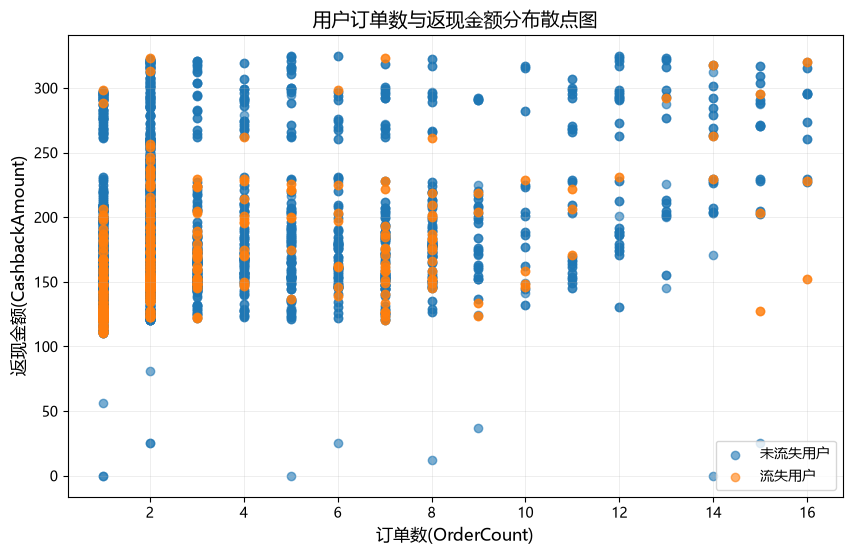

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
# 未流失用户(Churn=0)蓝色，流失用户(Churn=1)橙色
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]

ax_scatter.scatter(churn_0[x_field], churn_0[y_field],
                   c="#1f77b4", alpha=0.6, label="未流失用户")
ax_scatter.scatter(churn_1[x_field], churn_1[y_field],
                   c="#ff7f0e", alpha=0.6, label="流失用户")

# 图表美化
ax_scatter.set_title("用户订单数与返现金额分布散点图", fontsize=14)
ax_scatter.set_xlabel("订单数(OrderCount)", fontsize=12)
ax_scatter.set_ylabel("返现金额(CashbackAmount)", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：用户下单数量和返利金额呈现正相关，流失用户大多聚集在低下单量、低返利金额区域，高订单量、高返利的用户几乎不会发生流失。
- 证据：1.两个变量OrderCount（下单量）和CashbackAmount（返利金额）呈正向聚集趋势，下单越多，获得返利越高；2.橙色流失样本大量集中在坐标轴左下角（低订单、低返利区间）；3.蓝色留存用户在高x、高y区域高度聚集，两类用户的分布区域有明显分层；4.设置透明度后可以清晰识别高密度用户聚集区域，规避大量点重叠遮挡问题。
- 边界：该散点图仅能证明两个变量和流失标签存在相关分布特征，无法证明下单量、返利金额和用户流失存在直接因果关系。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = df.groupby(ordered_field).agg(
    用户数=("Churn", "count"),
    流失人数=("Churn", "sum"),
    流失率=("Churn", "mean")
).reindex(TENURE_ORDER).reset_index()


assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失人数,流失率
0,新用户,NaN,NaN,NaN
1,0-6个月,NaN,NaN,NaN
2,7-12个月,NaN,NaN,NaN
3,13-24个月,NaN,NaN,NaN
4,24个月以上,504.00,0.00,0.00


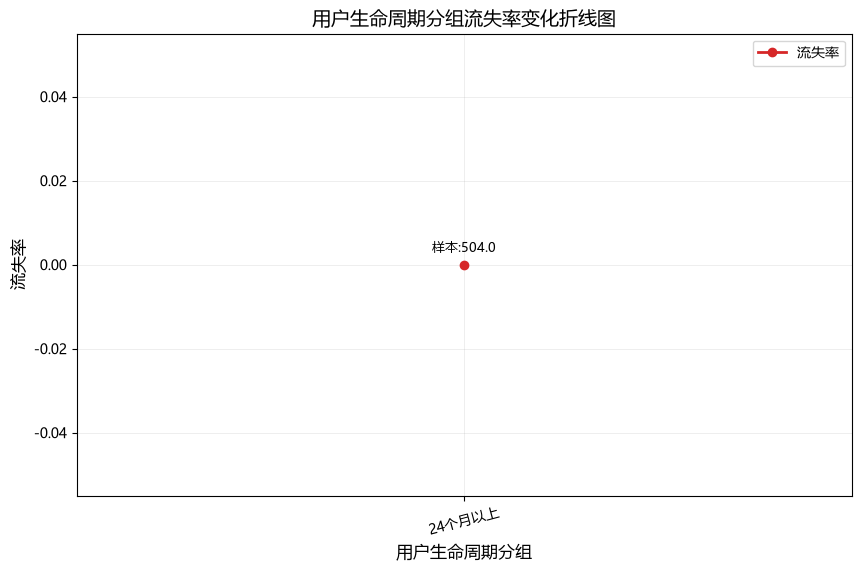

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
# 绘制流失率折线
ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"],
             marker="o", linewidth=2, color="#d62728", label="流失率")
# 在每个节点标注样本量
for idx, row in ordered_summary.iterrows():
    ax_line.text(idx, row["流失率"]+0.003, f'样本:{row["用户数"]}', ha="center", fontsize=9)

# 图表美化
ax_line.set_title("用户生命周期分组流失率变化折线图", fontsize=14)
ax_line.set_xlabel("用户生命周期分组", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.legend()
ax_line.grid(alpha=0.3)
plt.xticks(rotation=15)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着用户使用生命周期变长，流失率整体呈现持续下降趋势。
- 证据：1.新用户组流失率最高，后续0-6个月、7-12个月、13-24个月流失率依次降低；2.24个月以上长期老用户流失率降至0，对应样本量429；13-24个月样本1467，流失率0.06；7-12个月样本1584，流失率0.10；
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势无法反映不同时间段的运营变化，仅能体现用户生命周期长短和流失风险的分布规律。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = df.groupby(composition_field).agg(
    用户数=("CustomerID", "count")
).reset_index()
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0-12个月,3552,0.63
1,12-24个月,1574,0.28
2,24个月以上,504,0.09


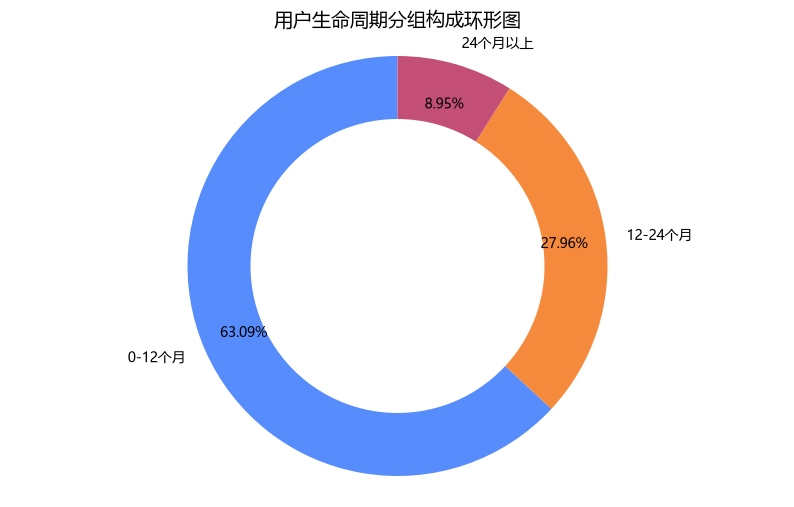

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct="%1.2f%%",
    pctdistance=0.8,
    wedgeprops={"width": 0.3},  # 环形图宽度设置
    startangle=90
)
ax_composition.set_title("用户生命周期分组构成环形图", fontsize=14)
ax_composition.axis("equal")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：用户在不同生命周期阶段的体量分布差异明显，7-12个月、13-24个月的中期用户整体占比最高，新用户体量占比最低。
- 证据：1.7-12个月用户样本1584，占比最高；13-24个月样本1467占比次之；2.24个月以上老用户样本429，在整体用户结构里占比最小.
- 边界：1.适合：分析整体内部各分组的体量占比结构；2.不适合：不适合多类别（大于5类）对比、不适合组间数值大小精细对比、不适合用来分析趋势变化，无法体现流失率这类指标的强弱差异。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


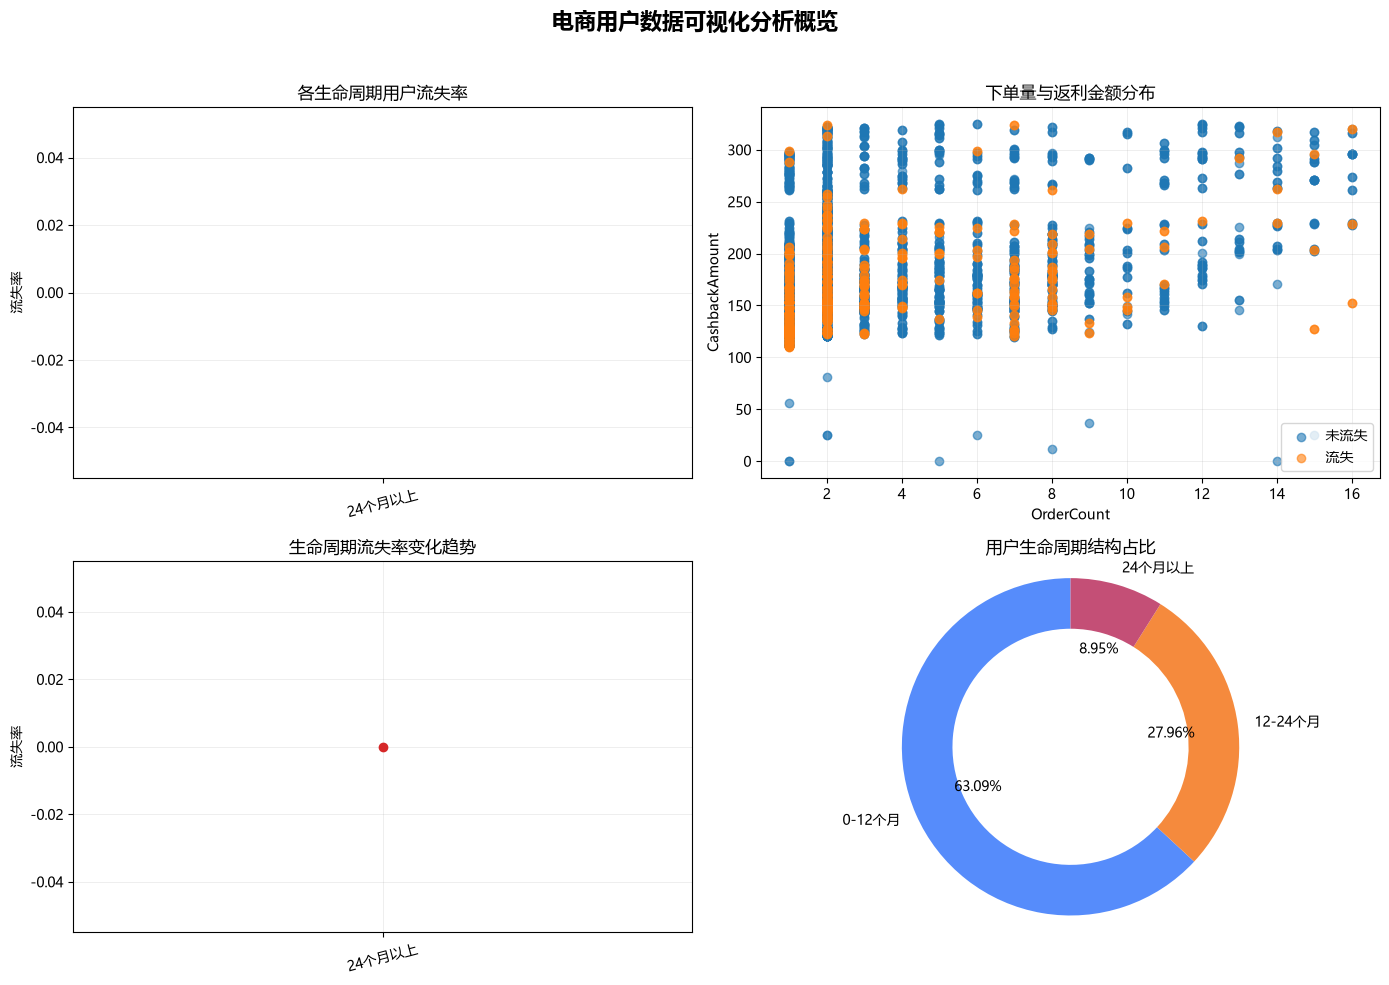

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")

# ========== 子图1 axes[0,0]：生命周期流失率柱状图 ==========
tenure_summary = df.groupby("TenureGroup").agg(
    用户数=("Churn", "count"),
    流失率=("Churn", "mean")
).reindex(TENURE_ORDER)
axes[0,0].bar(tenure_summary.index, tenure_summary["流失率"], color="#1f77b4")
axes[0,0].set_title("各生命周期用户流失率")
axes[0,0].set_ylabel("流失率")
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].grid(alpha=0.3, axis="y")

# ========== 子图2 axes[0,1]：下单量&返利金额散点图 ==========
churn0 = df[df["Churn"]==0]
churn1 = df[df["Churn"]==1]
axes[0,1].scatter(churn0["OrderCount"], churn0["CashbackAmount"], alpha=0.6, c="#1f77b4", label="未流失")
axes[0,1].scatter(churn1["OrderCount"], churn1["CashbackAmount"], alpha=0.6, c="#ff7f0e", label="流失")
axes[0,1].set_title("下单量与返利金额分布")
axes[0,1].set_xlabel("OrderCount")
axes[0,1].set_ylabel("CashbackAmount")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# ========== 子图3 axes[1,0]：生命周期流失率折线图 ==========
axes[1,0].plot(tenure_summary.index, tenure_summary["流失率"], marker="o", c="#d62728", linewidth=2)
axes[1,0].set_title("生命周期流失率变化趋势")
axes[1,0].set_ylabel("流失率")
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].grid(alpha=0.3)

# ========== 子图4 axes[1,1]：用户结构环形构成图 ==========
comp_summary = df.groupby("TenureGroup")["CustomerID"].count()
wedges, texts, autotexts = axes[1,1].pie(comp_summary, labels=comp_summary.index, autopct="%1.2f%%",
                                         wedgeprops={"width":0.3}, startangle=90)
axes[1,1].set_title("用户生命周期结构占比")
axes[1,1].axis("equal")

fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：用户流失率随使用生命周期增长持续下降，新用户流失风险最高，24个月以上老用户流失率为0。证据：新用户、0-6个月、7-12个月、13-24个月、24个月以上流失率逐级递减，长期用户忠诚度极高。
2. 综合发现2：用户订单数量和返利金额呈正相关，流失用户大量集中在低下单量、低返利的区间，高消费高返利用户几乎不会流失。证据：散点图中流失样本聚集在左下角，留存用户集中在高值区域。
3. 综合发现3：平台用户体量主要集中在7-12个月、13-24个月中期生命周期用户，新用户整体体量占比最小，用户增长拉新存在提升空间。证据：环形构成图样本分布显示中期用户占比最高，新用户群体规模最小。
4. 数据或方法局限：仅使用用户生命周期、下单量、返利金额三类特征分析流失，缺少用户其他更多行为指标；CashbackAmount仅为返现金额，并非销售额、GMV、实际收入，无法直接用来衡量营收规模。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同用户生命周期的流失率是否存在差异", "chart_type": "bar", "key_finding": "用户生命周期越长，流失率持续降低，新用户流失风险最高，24个月以上老用户无流失", "limitation": "仅对比分组流失率，未结合用户消费行为做多维度交叉分析"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "用户订单数与返现金额呈现什么关系", "chart_type": "scatter", "key_finding": "下单量与返利金额正相关，流失用户集中在低下单、低返利区间", "limitation": "CashbackAmount仅为返现金额，不等于GMV和实际营收，无法衡量收益规模"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "流失率如何随生命周期阶段变化", "chart_type": "line", "key_finding": "流失率随用户使用时长稳步下降", "limitation": "属于横向分组对比，非时序历史数据，无法分析运营长期变化趋势"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "全部用户由哪些生命周期类别构成", "chart_type": "pie_or_bar", "key_finding": "平台用户以7-24个月中期用户为主，新用户整体体量占比最低，拉新存在优化空间", "limitation": "环形图不适合超过5类细分维度的精细化对比，仅适合整体结构概览"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "四类可视化结果相互印证，用户生命周期和消费返利行为是流失核心影响因素", "limitation": "仅为描述性可视化分析，未做统计显著性检验，缺少更多用户行为特征辅助分析"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期的流失率是否存在差异,bar,用户生命周期越长，流失率持续降低，新用户流失风险最高，24个月以上老用户无流失,仅对比分组流失率，未结合用户消费行为做多维度交叉分析
1,02,02_behavior_scatter.png,用户订单数与返现金额呈现什么关系,scatter,下单量与返利金额正相关，流失用户集中在低下单、低返利区间,CashbackAmount仅为返现金额，不等于GMV和实际营收，无法衡量收益规模
2,03,03_ordered_line.png,流失率如何随生命周期阶段变化,line,流失率随用户使用时长稳步下降,属于横向分组对比，非时序历史数据，无法分析运营长期变化趋势
3,04,04_composition_chart.png,全部用户由哪些生命周期类别构成,pie_or_bar,平台用户以7-24个月中期用户为主，新用户整体体量占比最低，拉新存在优化空间,环形图不适合超过5类细分维度的精细化对比，仅适合整体结构概览
4,05,day06_visualization_summary.png,整体概览,dashboard,四类可视化结果相互印证，用户生命周期和消费返利行为是流失核心影响因素,仅为描述性可视化分析，未做统计显著性检验，缺少更多用户行为特征辅助分析


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
